In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

### Функция кодирования категориальных признаков

In [2]:
def categorical_encoding(categorical, df, target, threshold):
    for col in categorical:
        if df[col].nunique() < threshold:
            one_hot = pd.get_dummies(df[col], prefix=col, drop_first=True, dtype=int)
            df = pd.concat((df.drop(col, axis=1), one_hot), axis=1)
            df = df.drop(col, axis=1)
        else:
            mean_target = df.groupby(col)[target].mean()
            df[col] = df[col].map(mean_target)
    return df

### Чтение данных, переименование колонок

In [111]:
df = pd.read_csv('ks.csv')

In [4]:
df.head()

,Название,Категория,Главная категория,Валюта,Дедлайн,Дата публикации,Состояние,Инвесторов,Страна,Собрано в долларах,Цель в долларах
0,"Don't Call it a Comeback ""Telescopes""",Music,Music,USD,2013-01-10,2012-12-09 06:03:52,successful,23,US,600.00,600.00
1,Arcade County (Canceled),Games,Games,USD,2012-04-29,2012-03-30 23:40:45,canceled,5,US,71.00,9000.00
2,Hayashi Skate Co. Solar Skateboard backpack,Accessories,Fashion,CAD,2017-07-22,2017-05-23 23:00:13,canceled,8,CA,360.36,2391.77
3,Me & You Coordinating Sunglasses- Optical Qual...,Accessories,Fashion,USD,2016-11-18,2016-10-19 22:06:41,failed,20,US,502.00,10000.00
4,New Carts for Istanbul Street Food Vendors,Food,Food,USD,2015-05-17,2015-04-17 18:10:47,successful,62,US,2414.00,1400.00


In [112]:
columns = df.columns

In [113]:
columns

Index(['Название', 'Категория', 'Главная категория', 'Валюта', 'Дедлайн',
       'Дата публикации', 'Состояние', 'Инвесторов', 'Страна',
       'Собрано в долларах', 'Цель в долларах'],
      dtype='object')

In [114]:
df = df.rename(columns={'Название':'Title','Категория':'Category','Главная категория':'Main_category','Валюта':'Currency','Дедлайн':'Due_date','Дата публикации':'Pub_date',\
                        'Состояние':'Destiny','Инвесторов':'Investors','Страна':'Country','Собрано в долларах':'Money_collected','Цель в долларах':'Money_targeted'})

In [8]:
df.head()

,Title,Category,Main_category,Currency,Due_date,Pub_date,Destiny,Investors,Country,Money_collected,Money_targeted
0,"Don't Call it a Comeback ""Telescopes""",Music,Music,USD,2013-01-10,2012-12-09 06:03:52,successful,23,US,600.00,600.00
1,Arcade County (Canceled),Games,Games,USD,2012-04-29,2012-03-30 23:40:45,canceled,5,US,71.00,9000.00
2,Hayashi Skate Co. Solar Skateboard backpack,Accessories,Fashion,CAD,2017-07-22,2017-05-23 23:00:13,canceled,8,CA,360.36,2391.77
3,Me & You Coordinating Sunglasses- Optical Qual...,Accessories,Fashion,USD,2016-11-18,2016-10-19 22:06:41,failed,20,US,502.00,10000.00
4,New Carts for Istanbul Street Food Vendors,Food,Food,USD,2015-05-17,2015-04-17 18:10:47,successful,62,US,2414.00,1400.00


### Выделение и кодирование таргета

In [54]:
df['Destiny'].value_counts()

,count
Destiny,
failed,197719
successful,133956
canceled,38779
undefined,3562
live,2799
suspended,1846


In [116]:
df.loc[(df['Destiny'] == 'live'),'target'] = 1

In [120]:
df.loc[(df['Destiny'] == 'suspended'),'target'] = 0

In [121]:
df['target'].value_counts()

,count
target,
0.0,241906
1.0,136755


### Выделение признаков из дат

In [122]:
df['Due_date'] = pd.to_datetime(df['Due_date'])
df['Pub_date'] = pd.to_datetime(df['Pub_date'])
df['time_to_collect'] = (df['Due_date'] - df['Pub_date']).dt.days
df['day_of_pub'] = df['Pub_date'].dt.day_of_week

In [24]:
df.head()

,Title,Category,Main_category,Currency,Investors,Country,Money_collected,Money_targeted,target,time_to_collect,day_of_pub
0,"Don't Call it a Comeback ""Telescopes""",Music,Music,USD,23,US,600.00,600.00,1,31,6
1,Arcade County (Canceled),Games,Games,USD,5,US,71.00,9000.00,0,29,4
2,Hayashi Skate Co. Solar Skateboard backpack,Accessories,Fashion,CAD,8,CA,360.36,2391.77,0,59,1
3,Me & You Coordinating Sunglasses- Optical Qual...,Accessories,Fashion,USD,20,US,502.00,10000.00,0,29,2
4,New Carts for Istanbul Street Food Vendors,Food,Food,USD,62,US,2414.00,1400.00,1,29,4


In [123]:
df['target'] = df['target'].astype('int16')

In [124]:
df = df.drop(['Destiny','Pub_date','Due_date'], axis=1)

In [29]:
df['Main_category'].value_counts()

,count
Main_category,
Film & Video,63585
Music,51918
Publishing,39874
Games,35231
Technology,32569
Design,30070
Art,28153
Food,24602
Fashion,22816


In [31]:
df['Category'].value_counts().head(5)

,count
Category,
Product Design,22314
Documentary,16139
Music,15727
Tabletop Games,14180
Shorts,12357


### Кодирование цифровых признаков

In [42]:
numeric = df.describe().columns

<Axes: >

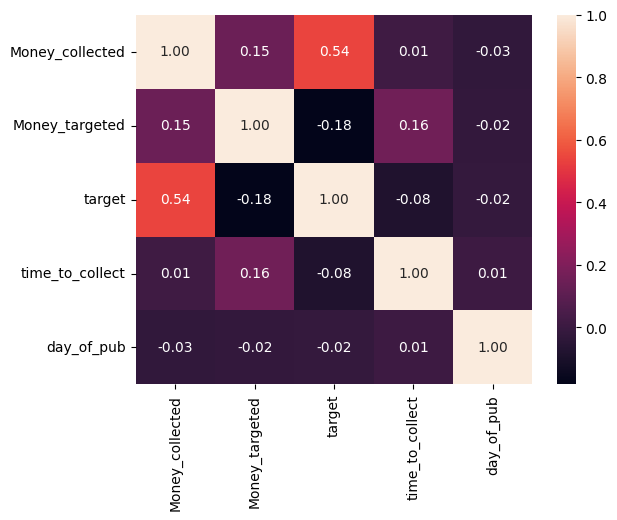

In [43]:
sns.heatmap(df[numeric].corr(method='kendall'), annot=True, fmt='.2f')

In [35]:
import scipy.stats as st

In [37]:
st.normaltest(df['Money_collected'])

NormaltestResult(statistic=1412803.7680396736, pvalue=0.0)

<Axes: xlabel='Investors', ylabel='Density'>

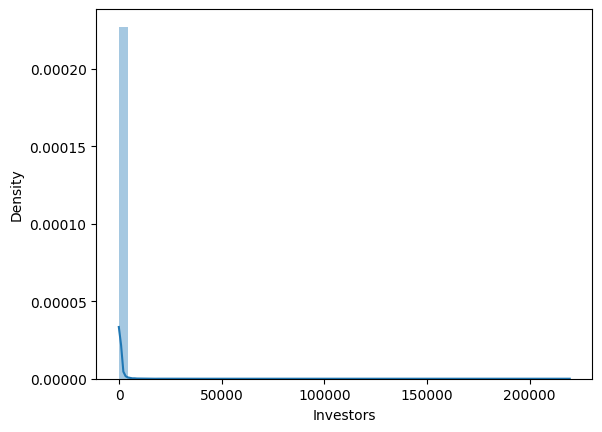

In [39]:
sns.distplot(df['Investors'])

In [125]:
df = df.drop('Investors',axis=1)

### Кодирование категориальных признаков

In [126]:
categorical = df.describe(include='object').columns

In [127]:
df.describe(include='object')

,Title,Category,Main_category,Currency,Country
count,378657,378661,378661,378661,378661
unique,375764,159,15,14,23
top,New EP/Music Development,Product Design,Film & Video,USD,US
freq,41,22314,63585,295365,292627


In [47]:
cat = categorical.to_list()

In [48]:
type(cat)

list

In [128]:
for col in ['Main_category','Currency']:
  one_hot = pd.get_dummies(df[col], prefix=col, drop_first=True, dtype=int)
  df = pd.concat((df.drop(col, axis=1), one_hot), axis=1)

In [76]:
df.head()

,Title,Category,Investors,Country,Money_collected,Money_targeted,target,time_to_collect,day_of_pub,Main_category_Comics,...,Currency_EUR,Currency_GBP,Currency_HKD,Currency_JPY,Currency_MXN,Currency_NOK,Currency_NZD,Currency_SEK,Currency_SGD,Currency_USD
0,"Don't Call it a Comeback ""Telescopes""",0.414065,23,0.379456,600.00,600.00,1,31,6,0,...,0,0,0,0,0,0,0,0,0,1
1,Arcade County (Canceled),0.248295,5,0.379456,71.00,9000.00,0,29,4,0,...,0,0,0,0,0,0,0,0,0,1
2,Hayashi Skate Co. Solar Skateboard backpack,0.355766,8,0.289103,360.36,2391.77,0,59,1,0,...,0,0,0,0,0,0,0,0,0,0
3,Me & You Coordinating Sunglasses- Optical Qual...,0.355766,20,0.379456,502.00,10000.00,0,29,2,0,...,0,0,0,0,0,0,0,0,0,1
4,New Carts for Istanbul Street Food Vendors,0.290264,62,0.379456,2414.00,1400.00,1,29,4,0,...,0,0,0,0,0,0,0,0,0,1


In [129]:
for col in ['Category','Country']:
  mean_target = df.groupby(col)['target'].mean()
  df[col] = df[col].map(mean_target)

### Выделение признаков из текста

#### Лемматизация

In [71]:
data = df.copy()

In [72]:
import nltk
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [73]:
wnl = WordNetLemmatizer()
list1 = ['kites', 'babies', 'dogs', 'flys','flew','smiling',
		'driving', 'died', 'tried', 'feet']
for words in list1:
	print(words + " ---> " + wnl.lemmatize(words))

kites ---> kite
babies ---> baby
dogs ---> dog
flys ---> fly
flew ---> flew
smiling ---> smiling
driving ---> driving
died ---> died
tried ---> tried
feet ---> foot


In [77]:
data['Title']

,Title
0,"Don't Call it a Comeback ""Telescopes"""
1,Arcade County (Canceled)
2,Hayashi Skate Co. Solar Skateboard backpack
3,Me & You Coordinating Sunglasses- Optical Qual...
4,New Carts for Istanbul Street Food Vendors
...,...
378656,Kitten Mittens - is your cat making too much N...
378657,TurnAround//The End Needs A Beginning Album Re...
378658,Celtic inspired band looking to move forward w...
378659,Listening & Speaking in Virtual Reality: 5 Int...


In [86]:
clear_bag = []
for word in data['Title']:
  if type(word) == float:
    continue
  clear_bag.append(wnl.lemmatize(str(word.split())))

In [87]:
clear_bag[0:10]

['["Don\'t", \'Call\', \'it\', \'a\', \'Comeback\', \'"Telescopes"\']',
 "['Arcade', 'County', '(Canceled)']",
 "['Hayashi', 'Skate', 'Co.', 'Solar', 'Skateboard', 'backpack']",
 "['Me', '&', 'You', 'Coordinating', 'Sunglasses-', 'Optical', 'Quality', 'Sunlens']",
 "['New', 'Carts', 'for', 'Istanbul', 'Street', 'Food', 'Vendors']",
 "['New', 'Improv', 'Comedy', 'Venue', 'in', 'Des', 'Moines']",
 "['The', 'Seer', 'and', 'the', 'Sword']",
 "['The', 'Wild', 'World', 'of', 'Ogots', '-', 'YOU', 'Become', 'an', 'Ogot', '(Commissions)']",
 "['VIGATAR,', 'the', 'fitness-machine', 'that', 'lets', 'you', 'play', 'videogames']",
 "['Escape', 'Room', 'Palm', 'Springs', '-', 'Real', 'Life', 'Escape', 'Game']"]

#### TF-IDF

In [89]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [90]:
tfidf = TfidfVectorizer()
tfidf.fit(clear_bag)
tfidf.vocabulary_[10]

{'don': 36604,
 'call': 21007,
 'it': 65202,
 'comeback': 27299,
 'telescopes': 128364,
 'arcade': 8194,
 'county': 29368,
 'canceled': 21358,
 'hayashi': 57243,
 'skate': 117301,
 'co': 26484,
 'solar': 119617,
 'skateboard': 117304,
 'backpack': 11290,
 'me': 81120,
 'you': 145169,
 'coordinating': 28680,
 'sunglasses': 124948,
 'optical': 93325,
 'quality': 103972,
 'sunlens': 124968,
 'new': 89281,
 'carts': 22375,
 'for': 48030,
 'istanbul': 65161,
 'street': 123908,
 'food': 47858,
 'vendors': 137632,
 'improv': 62788,
 'comedy': 27312,
 'venue': 137742,
 'in': 62843,
 'des': 34099,
 'moines': 84654,
 'the': 129167,
 'seer': 113822,
 'and': 6703,
 'sword': 126187,
 'wild': 142102,
 'world': 143409,
 'of': 92158,
 'ogots': 92272,
 'become': 13444,
 'an': 6550,
 'ogot': 92271,
 'commissions': 27463,
 'vigatar': 138380,
 'fitness': 46506,
 'machine': 77824,
 'that': 129138,
 'lets': 74266,
 'play': 99507,
 'videogames': 138275,
 'escape': 42254,
 'room': 109862,
 'palm': 95032,
 'sp

In [92]:
tfidf_ = pd.DataFrame(tfidf.transform([data['Title'][0]]).T.todense(),
                  index=tfidf.get_feature_names_out(),
                  columns=['tfidf'])

tfidf_.sort_values('tfidf', ascending=False)[:10]

,tfidf
telescopes,0.616997
comeback,0.501899
call,0.395890
don,0.360684
it,0.283885
pilloohs,0.000000
pillitteri,0.000000
pilllar,0.000000
pillo,0.000000
pillocks,0.000000


In [94]:
def tfidf_s(s):
  list_m = tfidf.transform([s]).T.todense()
  return list_m[list_m.nonzero()[0]].mean()
tfidf_s(data['Title'][0])

0.43187085559288796

In [95]:
data['tf'] = data['Title'][0:1000].apply(tfidf_s)

In [96]:
data.head()

,Title,Category,Investors,Country,Money_collected,Money_targeted,target,time_to_collect,day_of_pub,Main_category_Comics,...,Currency_GBP,Currency_HKD,Currency_JPY,Currency_MXN,Currency_NOK,Currency_NZD,Currency_SEK,Currency_SGD,Currency_USD,tf
0,"Don't Call it a Comeback ""Telescopes""",0.414065,23,0.379456,600.00,600.00,1,31,6,0,...,0,0,0,0,0,0,0,0,1,0.431871
1,Arcade County (Canceled),0.248295,5,0.379456,71.00,9000.00,0,29,4,0,...,0,0,0,0,0,0,0,0,1,0.550241
2,Hayashi Skate Co. Solar Skateboard backpack,0.355766,8,0.289103,360.36,2391.77,0,59,1,0,...,0,0,0,0,0,0,0,0,0,0.398926
3,Me & You Coordinating Sunglasses- Optical Qual...,0.355766,20,0.379456,502.00,10000.00,0,29,2,0,...,0,0,0,0,0,0,0,0,1,0.358630
4,New Carts for Istanbul Street Food Vendors,0.290264,62,0.379456,2414.00,1400.00,1,29,4,0,...,0,0,0,0,0,0,0,0,1,0.351789


In [99]:
data[['target','tf']][0:1000].corr()

,target,tf
target,1.000000,-0.029304
tf,-0.029304,1.000000


#### Sentiment Analysis

In [100]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('punkt')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [101]:
sid = SentimentIntensityAnalyzer()

In [105]:
sentence = 'What is it to be a good doctor in a good hospital'
sid.polarity_scores(sentence)

{'neg': 0.0, 'neu': 0.58, 'pos': 0.42, 'compound': 0.7003}

In [106]:
def sent_a(s):
  ss = sid.polarity_scores(s)
  return ss['compound']

In [107]:
data['sentiment'] = data['Title'][0:1000].apply(sent_a)

In [108]:
data.head(100)

,Title,Category,Investors,Country,Money_collected,Money_targeted,target,time_to_collect,day_of_pub,Main_category_Comics,...,Currency_HKD,Currency_JPY,Currency_MXN,Currency_NOK,Currency_NZD,Currency_SEK,Currency_SGD,Currency_USD,tf,sentiment
0,"Don't Call it a Comeback ""Telescopes""",0.414065,23,0.379456,600.00,600.00,1,31,6,0,...,0,0,0,0,0,0,0,1,0.431871,0.0000
1,Arcade County (Canceled),0.248295,5,0.379456,71.00,9000.00,0,29,4,0,...,0,0,0,0,0,0,0,1,0.550241,0.0000
2,Hayashi Skate Co. Solar Skateboard backpack,0.355766,8,0.289103,360.36,2391.77,0,59,1,0,...,0,0,0,0,0,0,0,0,0.398926,0.0000
3,Me & You Coordinating Sunglasses- Optical Qual...,0.355766,20,0.379456,502.00,10000.00,0,29,2,0,...,0,0,0,0,0,0,0,1,0.358630,0.0000
4,New Carts for Istanbul Street Food Vendors,0.290264,62,0.379456,2414.00,1400.00,1,29,4,0,...,0,0,0,0,0,0,0,1,0.351789,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,The Heroes of CircleHaven graphic novel (Cance...,0.504604,21,0.379456,1190.00,15000.00,0,29,1,1,...,0,0,0,0,0,0,0,1,0.330741,0.6808
96,SPACE ART FEATURING ASTRONAUTS #WeBelieveInAst...,0.380805,77,0.379456,15808.00,15000.00,1,59,4,0,...,0,0,0,0,0,0,0,1,0.423088,0.0000
97,Europe By The Books Webseries,0.297293,48,0.379456,4004.55,3500.00,1,46,2,0,...,0,0,0,0,0,0,0,1,0.419856,0.0000
98,The Space Needle Lamp - Tribute to Seattle's F...,0.367437,5,0.379456,104.00,5350.00,0,29,3,0,...,0,0,0,0,0,0,0,1,0.315375,0.0000


In [109]:
data[['target','tf','sentiment']][0:1000].corr()

,target,tf,sentiment
target,1.000000,-0.029304,-0.051541
tf,-0.029304,1.000000,-0.098504
sentiment,-0.051541,-0.098504,1.000000


In [130]:
df.head()

,Title,Category,Country,Money_collected,Money_targeted,target,time_to_collect,day_of_pub,Main_category_Comics,Main_category_Crafts,...,Currency_EUR,Currency_GBP,Currency_HKD,Currency_JPY,Currency_MXN,Currency_NOK,Currency_NZD,Currency_SEK,Currency_SGD,Currency_USD
0,"Don't Call it a Comeback ""Telescopes""",0.414065,0.379456,600.00,600.00,1,31,6,0,0,...,0,0,0,0,0,0,0,0,0,1
1,Arcade County (Canceled),0.248295,0.379456,71.00,9000.00,0,29,4,0,0,...,0,0,0,0,0,0,0,0,0,1
2,Hayashi Skate Co. Solar Skateboard backpack,0.355766,0.289103,360.36,2391.77,0,59,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Me & You Coordinating Sunglasses- Optical Qual...,0.355766,0.379456,502.00,10000.00,0,29,2,0,0,...,0,0,0,0,0,0,0,0,0,1
4,New Carts for Istanbul Street Food Vendors,0.290264,0.379456,2414.00,1400.00,1,29,4,0,0,...,0,0,0,0,0,0,0,0,0,1


### Разбиение датасета и импортирование библиотек

In [131]:
df = df.drop('Title', axis=1)

In [ ]:
df.head()

In [132]:
X = df.drop('target', axis=1)
Y = df['target']

In [133]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

In [134]:
X_train,X_test, Y_train,Y_test = train_test_split(X,Y,test_size=0.25)

In [135]:
Y.value_counts()

,count
target,
0,241906
1,136755


### Логистическая регрессия

In [136]:
pipe_log = Pipeline([('Scaler',StandardScaler()),('LR',LogisticRegression(class_weight='balanced'))])
pipe_log.fit(X_train,Y_train)

Pipeline(steps=[('Scaler', StandardScaler()),
                ('LR', LogisticRegression(class_weight='balanced'))])

In [ ]:
pipe_log.classes_

In [137]:
print(f'Accuracy равно: {accuracy_score(Y_test, pipe_log.predict(X_test)):.3f}' )
print(f'Precision равно: {precision_score(Y_test, pipe_log.predict(X_test)):.3f}' )
print(f'Recall равно: {recall_score(Y_test, pipe_log.predict(X_test)):.3f}' )
print(f'F-мера равно: {f1_score(Y_test, pipe_log.predict(X_test)):.3f}' )

Accuracy равно: 0.861
Precision равно: 0.793
Recall равно: 0.834
F-мера равно: 0.813


In [138]:
pipe_mm = Pipeline([('Scaler',MinMaxScaler()),('LR',LogisticRegression(class_weight='balanced', solver='sag'))])
pipe_mm.fit(X_train,Y_train)

Pipeline(steps=[('Scaler', MinMaxScaler()),
                ('LR',
                 LogisticRegression(class_weight='balanced', solver='sag'))])

In [139]:
print(f'Accuracy равно: {accuracy_score(Y_test, pipe_mm.predict(X_test)):.3f}' )
print(f'Precision равно: {precision_score(Y_test, pipe_mm.predict(X_test)):.3f}' )
print(f'Recall равно: {recall_score(Y_test, pipe_mm.predict(X_test)):.3f}' )
print(f'F-мера равно: {f1_score(Y_test, pipe_mm.predict(X_test)):.3f}' )

Accuracy равно: 0.659
Precision равно: 0.524
Recall равно: 0.635
F-мера равно: 0.574


### PR, AUC

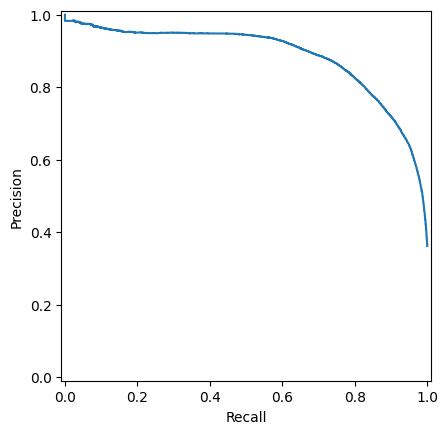

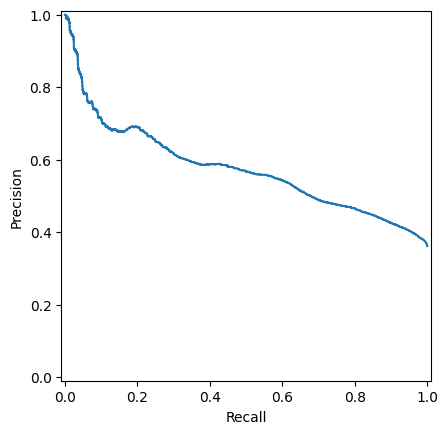

In [140]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.metrics import PrecisionRecallDisplay

precision_l, recall_l, thresholds_l = precision_recall_curve(Y_test, pipe_log.predict_proba(X_test)[:, 1])
precision_m, recall_m, thresholds_m = precision_recall_curve(Y_test, pipe_mm.predict_proba(X_test)[:, 1])

PrecisionRecallDisplay(precision=precision_l, recall=recall_l).plot()
PrecisionRecallDisplay(precision=precision_m, recall=recall_m).plot()

In [141]:
### Посчитаем PR-AUC
auc(recall_l, precision_l)

0.8876342446864208

In [142]:
auc(recall_m, precision_m)

0.574590434401638

### Линейный SVM

In [143]:
from sklearn.svm import LinearSVC
pipe = Pipeline([('Scaler',StandardScaler()),('LR',LinearSVC(class_weight='balanced'))])
pipe.fit(X_train,Y_train)

Pipeline(steps=[('Scaler', StandardScaler()),
                ('LR', LinearSVC(class_weight='balanced'))])

In [144]:
print(f'Accuracy равно: {accuracy_score(Y_test, pipe.predict(X_test)):.3f}' )
print(f'Precision равно: {precision_score(Y_test, pipe.predict(X_test)):.3f}' )
print(f'Recall равно: {recall_score(Y_test, pipe.predict(X_test)):.3f}' )
print(f'F-мера равно: {f1_score(Y_test, pipe.predict(X_test)):.3f}' )

Accuracy равно: 0.740
Precision равно: 0.628
Recall равно: 0.690
F-мера равно: 0.657


#### Подбор гиперпараметров модели

In [145]:
pipe.get_params()

{'memory': None,
 'steps': [('Scaler', StandardScaler()),
  ('LR', LinearSVC(class_weight='balanced'))],
 'verbose': False,
 'Scaler': StandardScaler(),
 'LR': LinearSVC(class_weight='balanced'),
 'Scaler__copy': True,
 'Scaler__with_mean': True,
 'Scaler__with_std': True,
 'LR__C': 1.0,
 'LR__class_weight': 'balanced',
 'LR__dual': 'auto',
 'LR__fit_intercept': True,
 'LR__intercept_scaling': 1,
 'LR__loss': 'squared_hinge',
 'LR__max_iter': 1000,
 'LR__multi_class': 'ovr',
 'LR__penalty': 'l2',
 'LR__random_state': None,
 'LR__tol': 0.0001,
 'LR__verbose': 0}

In [146]:
from sklearn.model_selection import GridSearchCV
params = {
    'LR__C':[1.0,1.1,1.2,1.3],
    'LR__loss': ['hinge','squared_hinge'],
    'LR__penalty':['l1','l2']
}

In [147]:
search = GridSearchCV(pipe, params, cv=2)
search.fit(X_train,Y_train)
print(f"Best parameter (CV score={search.best_score_:.5f}):")
print(search.best_params_)

Best parameter (CV score=0.87169):
{'LR__C': 1.3, 'LR__loss': 'hinge', 'LR__penalty': 'l2'}


### Модель с подобранными параметрами

In [148]:
pipe = Pipeline([('Scaler',StandardScaler()),('LR',LinearSVC(class_weight='balanced', C=1.3, loss='hinge'))])
pipe.fit(X_train,Y_train)
print(f'Precision равно: {precision_score(Y_test, pipe.predict(X_test)):.3f}' )
print(f'Recall равно: {recall_score(Y_test, pipe.predict(X_test)):.3f}' )
print(f'F-мера равно: {f1_score(Y_test, pipe.predict(X_test)):.3f}' )

Precision равно: 0.825
Recall равно: 0.859
F-мера равно: 0.841


In [149]:
pipe.predict_proba(X_test)

AttributeError: This 'Pipeline' has no attribute 'predict_proba'

### CalibratedClassifier

In [150]:
from sklearn.calibration import CalibratedClassifierCV
clf=CalibratedClassifierCV(pipe)
clf.fit(X_train, Y_train)
print(f'Precision равно: {precision_score(Y_test, pipe.predict(X_test)):.3f}' )
print(f'Recall равно: {recall_score(Y_test, pipe.predict(X_test)):.3f}' )
print(f'F-мера равно: {f1_score(Y_test, pipe.predict(X_test)):.3f}' )

Precision равно: 0.825
Recall равно: 0.859
F-мера равно: 0.841


In [151]:
clf.predict_proba(X_test.head(3))

array([[0.88578519, 0.11421481],
       [0.0466417 , 0.9533583 ],
       [0.61769712, 0.38230288]])

In [152]:
Y_test.head(3)

,target
289112,0
49829,1
82061,0


### Нелинейный SVM

In [ ]:
from sklearn.svm import SVC
pipe = Pipeline([('Scaler',StandardScaler()),('LR',SVC(class_weight='balanced', probability=True))])
pipe.fit(X_train,Y_train)
print(f'Accuracy равно: {accuracy_score(Y_test, pipe.predict(X_test)):.3f}' )
print(f'Precision равно: {precision_score(Y_test, pipe.predict(X_test)):.3f}' )
print(f'Recall равно: {recall_score(Y_test, pipe.predict(X_test)):.3f}' )
print(f'F-мера равно: {f1_score(Y_test, pipe.predict(X_test)):.3f}' )

### KNN - K-Nearest Neighbours

In [153]:
from sklearn.neighbors import KNeighborsClassifier

In [154]:
pipe = Pipeline([('Scaler',StandardScaler()),('KNN',KNeighborsClassifier(n_neighbors=5))])
pipe.fit(X_train,Y_train)
print(f'Precision равно: {precision_score(Y_test, pipe.predict(X_test)):.3f}' )
print(f'Recall равно: {recall_score(Y_test, pipe.predict(X_test)):.3f}' )
print(f'F-мера равно: {f1_score(Y_test, pipe.predict(X_test)):.3f}' )

Precision равно: 0.818
Recall равно: 0.761
F-мера равно: 0.788
